In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import random
import os
from sklearn.neighbors import NearestNeighbors
import igraph as ig
import leidenalg
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from statsmodels.stats.multitest import multipletests
from wompywompy import plot_alluvial
plt.style.use('default')  

ModuleNotFoundError: No module named 'leidenalg'

In [ ]:
# replace this path with the path for where the downloaded supplement file is located
supplement_file_path = "/home/nikki/Supplementary_data/"

# replace this path with output path
output_path = "/home/nikki/swarna2025_figs/figs/fig2/"

# Fig1

## a

In [8]:
# Processing df
pvals_path = os.path.join(supplement_file_path, "8cube_across_tissues/Tissue.csv")
pvals = pd.read_csv(pvals_path, index_col = "gene_name")
# Ensure proper dtype
pvals['Psi p-value'] = pvals['Psi p-value'].astype(float)
pvals['Zeta p-value'] = pvals['Zeta p-value'].astype(float)

# global testing correction for psi and zeta
_, pvals['Psi FDR'], _, _ = multipletests(pvals['Psi p-value'], method='fdr_bh')
_, pvals['Zeta FDR'], _, _ = multipletests(pvals['Zeta p-value'], method='fdr_bh')
fdr_thresh = 0.05
psi_thresh = 0.45
zeta_thresh = 0.45

filtered = pvals[
    (pvals['Psi FDR'] <= fdr_thresh) &
    (pvals['Zeta FDR'] <= fdr_thresh) &
    (pvals['Psi'] > psi_thresh) &
    (pvals['Zeta'] > zeta_thresh)
]

df_path = os.path.join(supplement_file_path, '8cube_across_tissues/psi_block_Tissue.csv')

df = pd.read_csv(df_path, index_col = "gene_name")
df = df.drop(["ensembl_id","Analysis_level", "Analysis_type"], axis = 1)
clusters = sorted(df.columns)
df = df.loc[filtered.index]


In [9]:

# Unsupervised clustering of psi_block scores
SEED = 45
np.random.seed(SEED)
random.seed(SEED)
# X = numpy array from the contribution score DataFrame
X = df.values  # shape (n_genes, 17)

# Build kNN graph — 10 neighbors usually works well
k = 10
nn = NearestNeighbors(n_neighbors=k, metric='cosine')
nn.fit(X)
distances, indices = nn.kneighbors(X)

# Construct edges: undirected graph
edges = []
for i in range(indices.shape[0]):
    for j in indices[i]:
        if i != j:
            edges.append((i, j))

# Build iGraph object
g = ig.Graph(edges=edges, directed=False)

# Run Leiden clustering
partition = leidenalg.find_partition(
    g, 
    leidenalg.RBConfigurationVertexPartition,
    seed=SEED  # Add this
)


# Get cluster labels
labels = np.array(partition.membership)
df['cluster'] = labels

cluster_profiles = df.groupby('cluster').mean().drop(columns='cluster', errors='ignore')


# Prepare heatmap data and sort columns alphabetically
heatmap_data = cluster_profiles
heatmap_data = heatmap_data[sorted(heatmap_data.columns)]

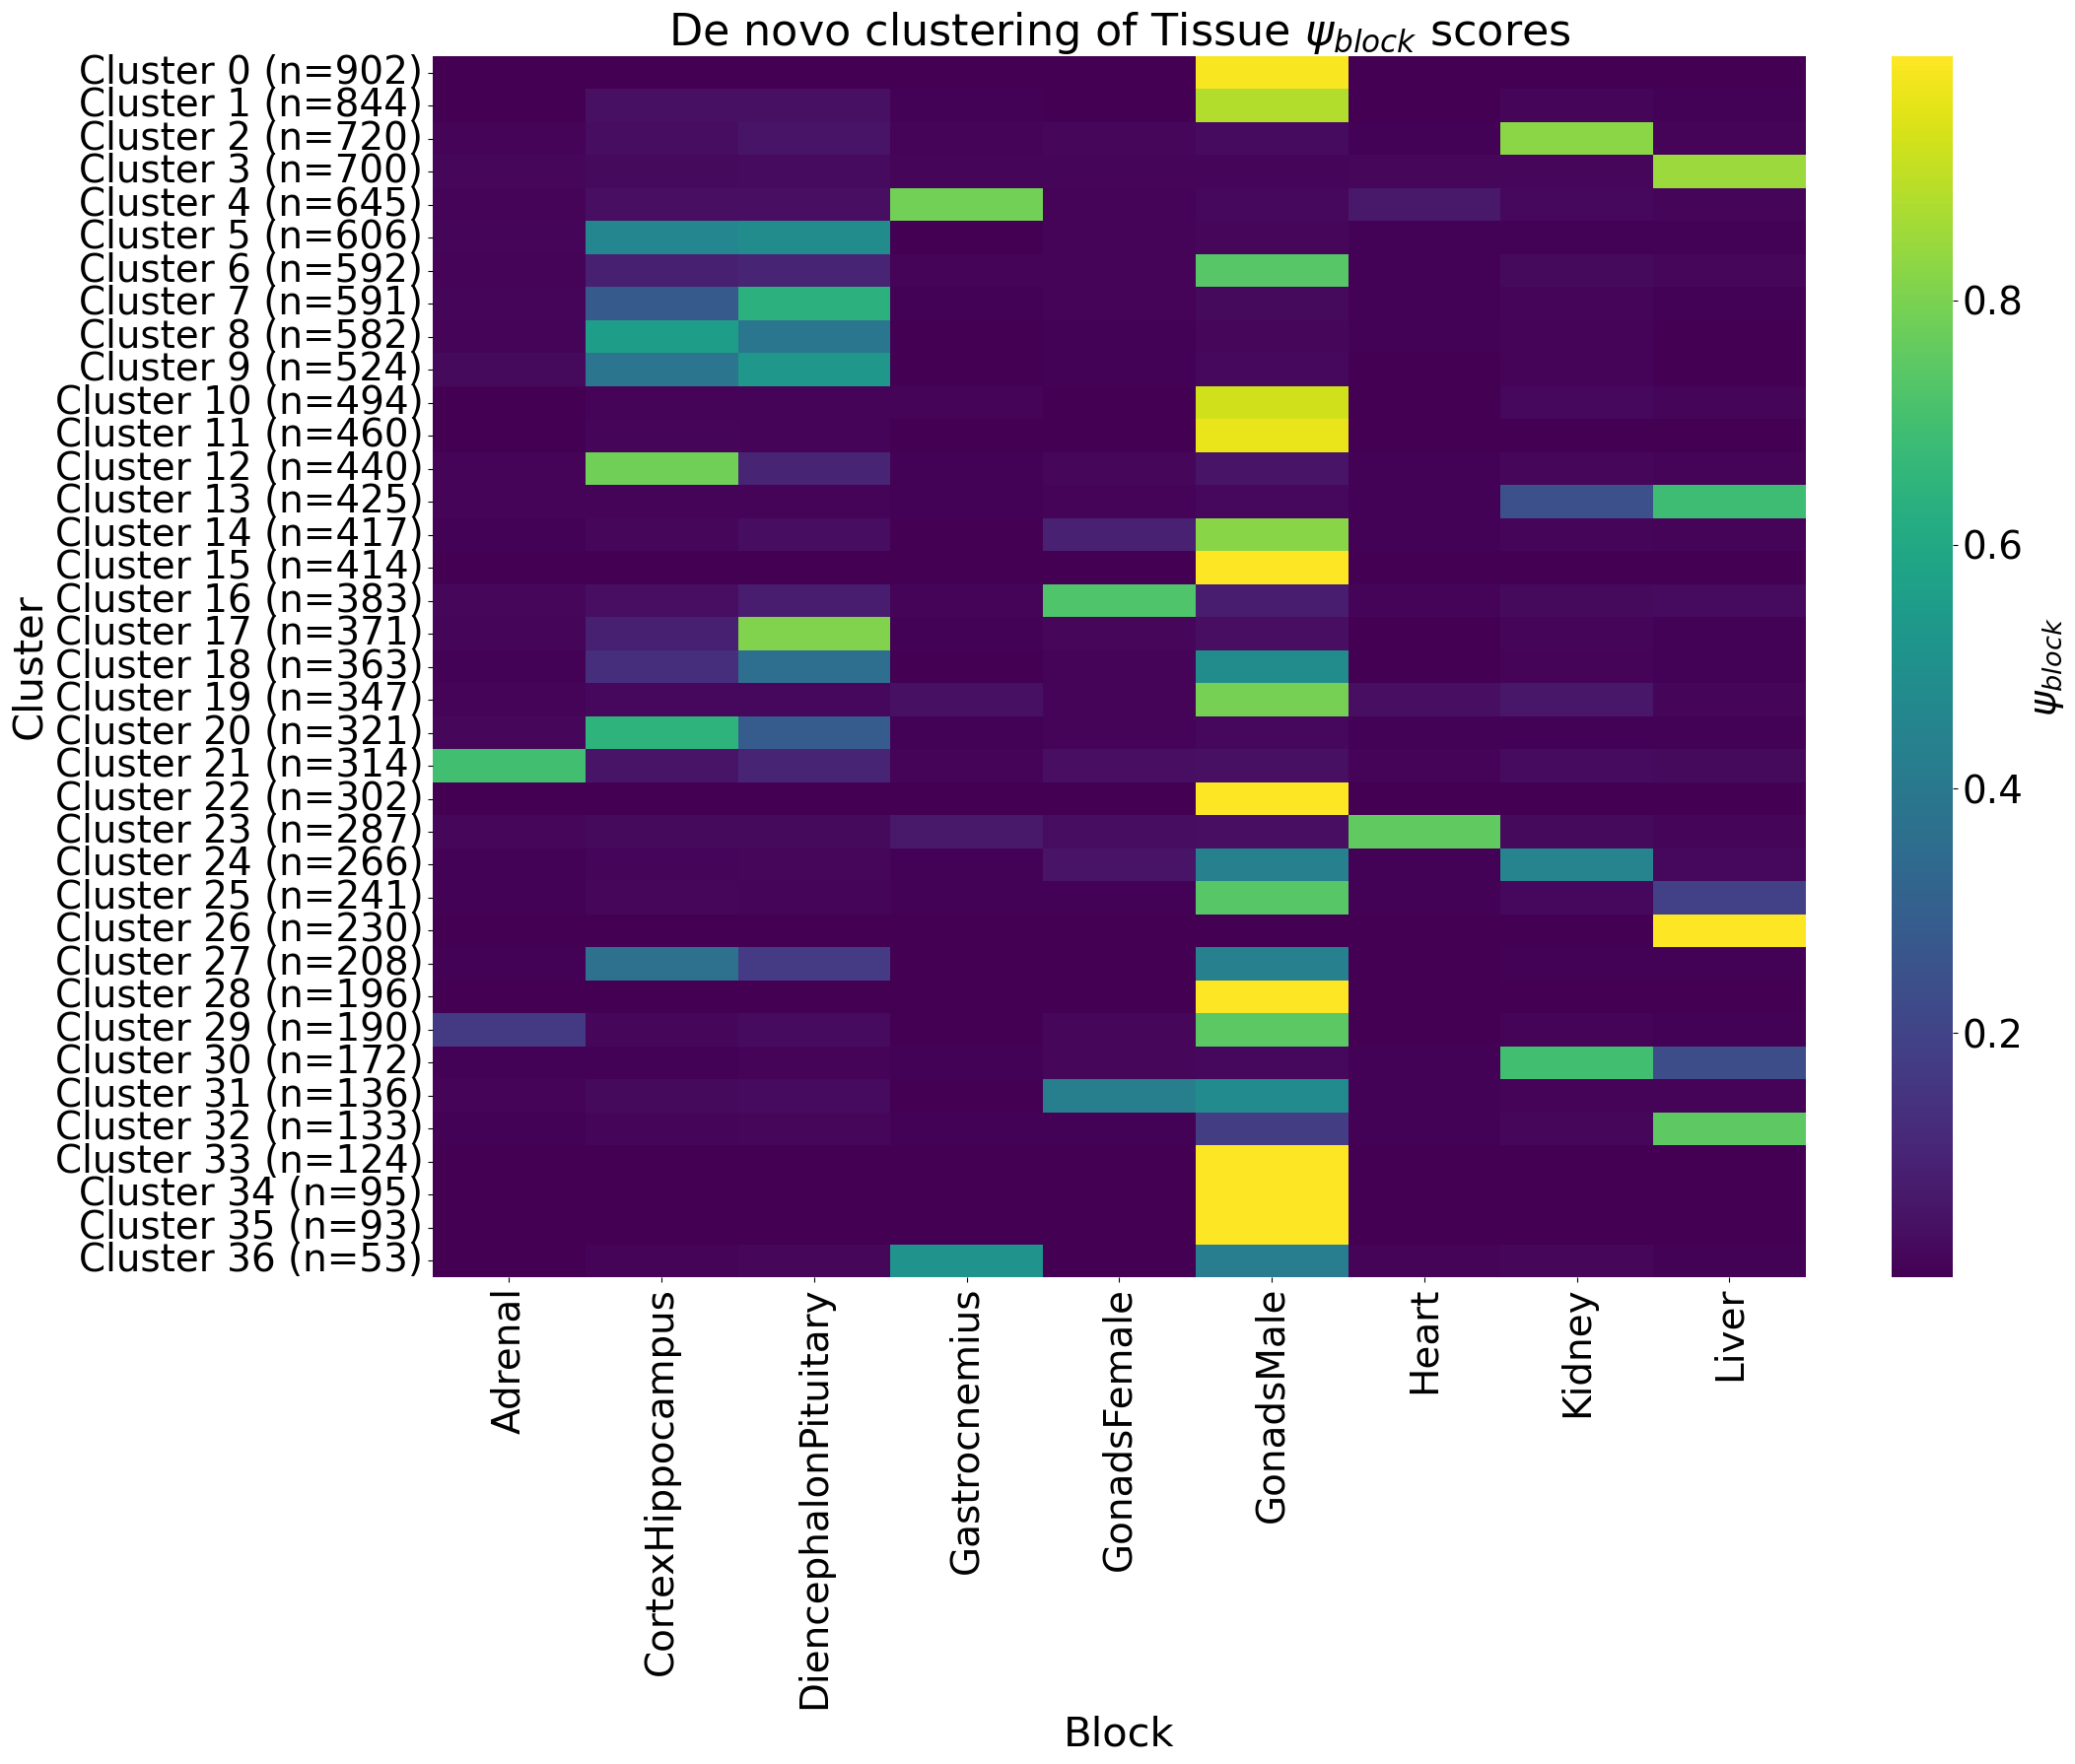

In [10]:
# Plotting heatmap of clusters

fontsize = 30
plt.figure(figsize=(22, 18))

# Count how many genes are in each cluster
gene_counts = df['cluster'].value_counts().sort_index()
y_labels = [f"Cluster {i} (n={gene_counts[i]})" for i in heatmap_data.index]

# Create heatmap with custom y-tick labels
ax = sns.heatmap(heatmap_data, cmap='viridis', xticklabels=True, yticklabels=y_labels)

# Add colorbar label
colorbar = ax.collections[0].colorbar
colorbar.set_label('$\psi_{{block}}$', fontsize=fontsize-2)
colorbar.ax.tick_params(labelsize=fontsize -2)

plt.title(fr"De novo clustering of Tissue $\psi_{{block}}$ scores", fontsize=fontsize+2)
plt.xlabel("Block", fontsize=fontsize)
plt.ylabel("Cluster", fontsize=fontsize)
plt.xticks(fontsize=fontsize-2, rotation = 90)
plt.yticks(fontsize=fontsize-2, rotation=0)
plt.tight_layout()
plt.show()
fig_out_path = os.path.join(output_path, "tissue_heatmap.png")

## b and c

Sorting Data with sorting algorithm = neighbornet
Sorting Distance matrix with algorithm neighbornet
Determining Optimal Cycle Start
neighbornet_objective for iteration 0 = 3051275970503867.0
neighbornet_objective for iteration 1 = 3181711585364682.0
neighbornet_objective for iteration 2 = 1402006120856413.0
neighbornet_objective for iteration 3 = 1401888815424294.0
neighbornet_objective for iteration 4 = 1367503773734152.0
neighbornet_objective for iteration 5 = 1366625957939198.0
neighbornet_objective for iteration 6 = 1429582339337031.0
neighbornet_objective for iteration 7 = 3102979322847482.0
neighbornet_objective for iteration 8 = 3140369995538836.0
neighbornet_objective for iteration 9 = 1424803274795309.0
neighbornet_objective for iteration 10 = 1425375600559295.0
neighbornet_objective for iteration 11 = 1351656976269071.0
neighbornet_objective for iteration 12 = 1351682427983241.0
neighbornet_objective for iteration 13 = 1351975649141605.0
neighbornet_objective for iteration 1

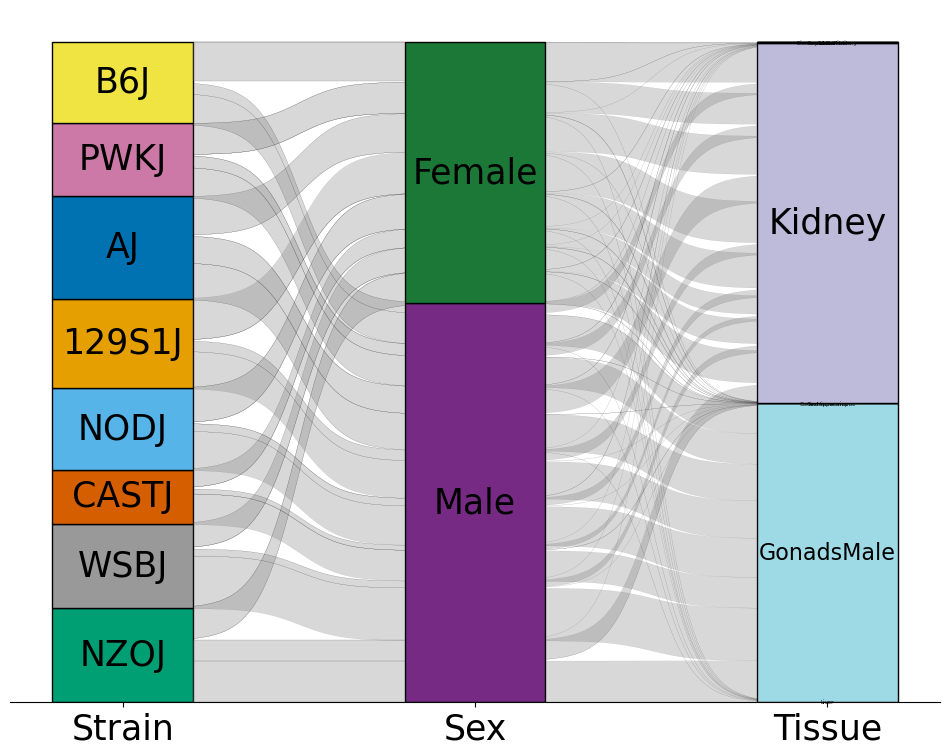

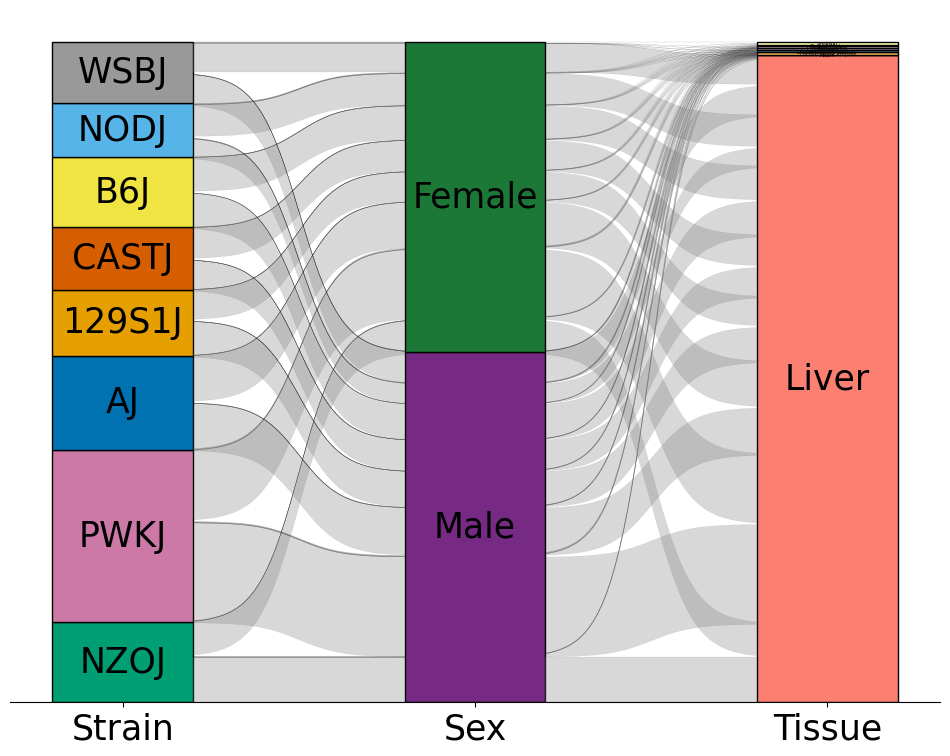

In [12]:
genes = ["Serpina1f", "Hpx"]
for gene_name in genes:
    pvals_path = os.path.join(supplement_file_path, f"8cube_across_tissues/{gene_name}_pseudobulk_wompwomp.csv")
    df = pd.read_csv(pvals_path)

    # cleaning out empty levels to improve effeciency
    df = df[df['umi_total'] > 0]
    df = df[['Sex', 'Genotype', 'Tissue', 'umi_total']]
    df = df.rename(columns={
        'Genotype': 'Strain'
    })
    df = df.groupby(['Sex', 'Strain', 'Tissue']).agg('sum').reset_index()

    color_dict = {
        "129S1J": "#E69F00",   # orange
        "NODJ": "#56B4E9",     # sky blue
        "NZOJ": "#009E73",     # green
        "B6J": "#F0E442",      # yellow
        "AJ": "#0072B2",       # deep blue
        "CASTJ": "#D55E00",    # vermillion
        "PWKJ": "#CC79A7",     # purple-pink
        "WSBJ": "#999999",      # gray
        "Male": "#762A83",   # violet
        "Female": "#1B7837",      # dark green
        "Gastrocnemius": "#8DD3C7",        # turquoise
        "Adrenal": "#FFFFB3",               # light yellow
        "Kidney": "#BEBADA",              # lavender
        "Liver": "#FB8072",                # coral
        "DiencephalonPituitary": "#80B1D3",# steel blue
        "CortexHippocampus": "#FDB462",           # peach
        "GOnadsMale": "#B3DE69",    # lime green
        "GonadsFemale": "#FCCDE5"          # pink

    }
    fig, order_dict = plot_alluvial(df, #pandas data frame  
                      # general function arguments
                      graphing_columns = ['Strain','Sex', 'Tissue'],optimize_column_order = False, column_weights = 'umi_total',
                                    color_alluvium = False, match_colors = False, verbose = True,
                                    sorting_algorithm = 'neighbornet', return_order_dict = True, color_dict = color_dict,
                                    save_height=12, save_width=9, default_text_size=25, alluvial_alpha=0.3,resolution=30)
    fig_out_path = os.path.join(output_path, f"{gene_name}_alluvial.png")
    fig[0].savefig(fig_out_path)

## d

In [10]:
subset_kidney_path = os.path.join(supplement_file_path, '8cube_other_tissues/Serpina1f_B6J_kidney.h5ad')
subset_kidney = ad.read_h5ad(subset_kidney_path)

/tmp/ipykernel_290611/1563335634.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


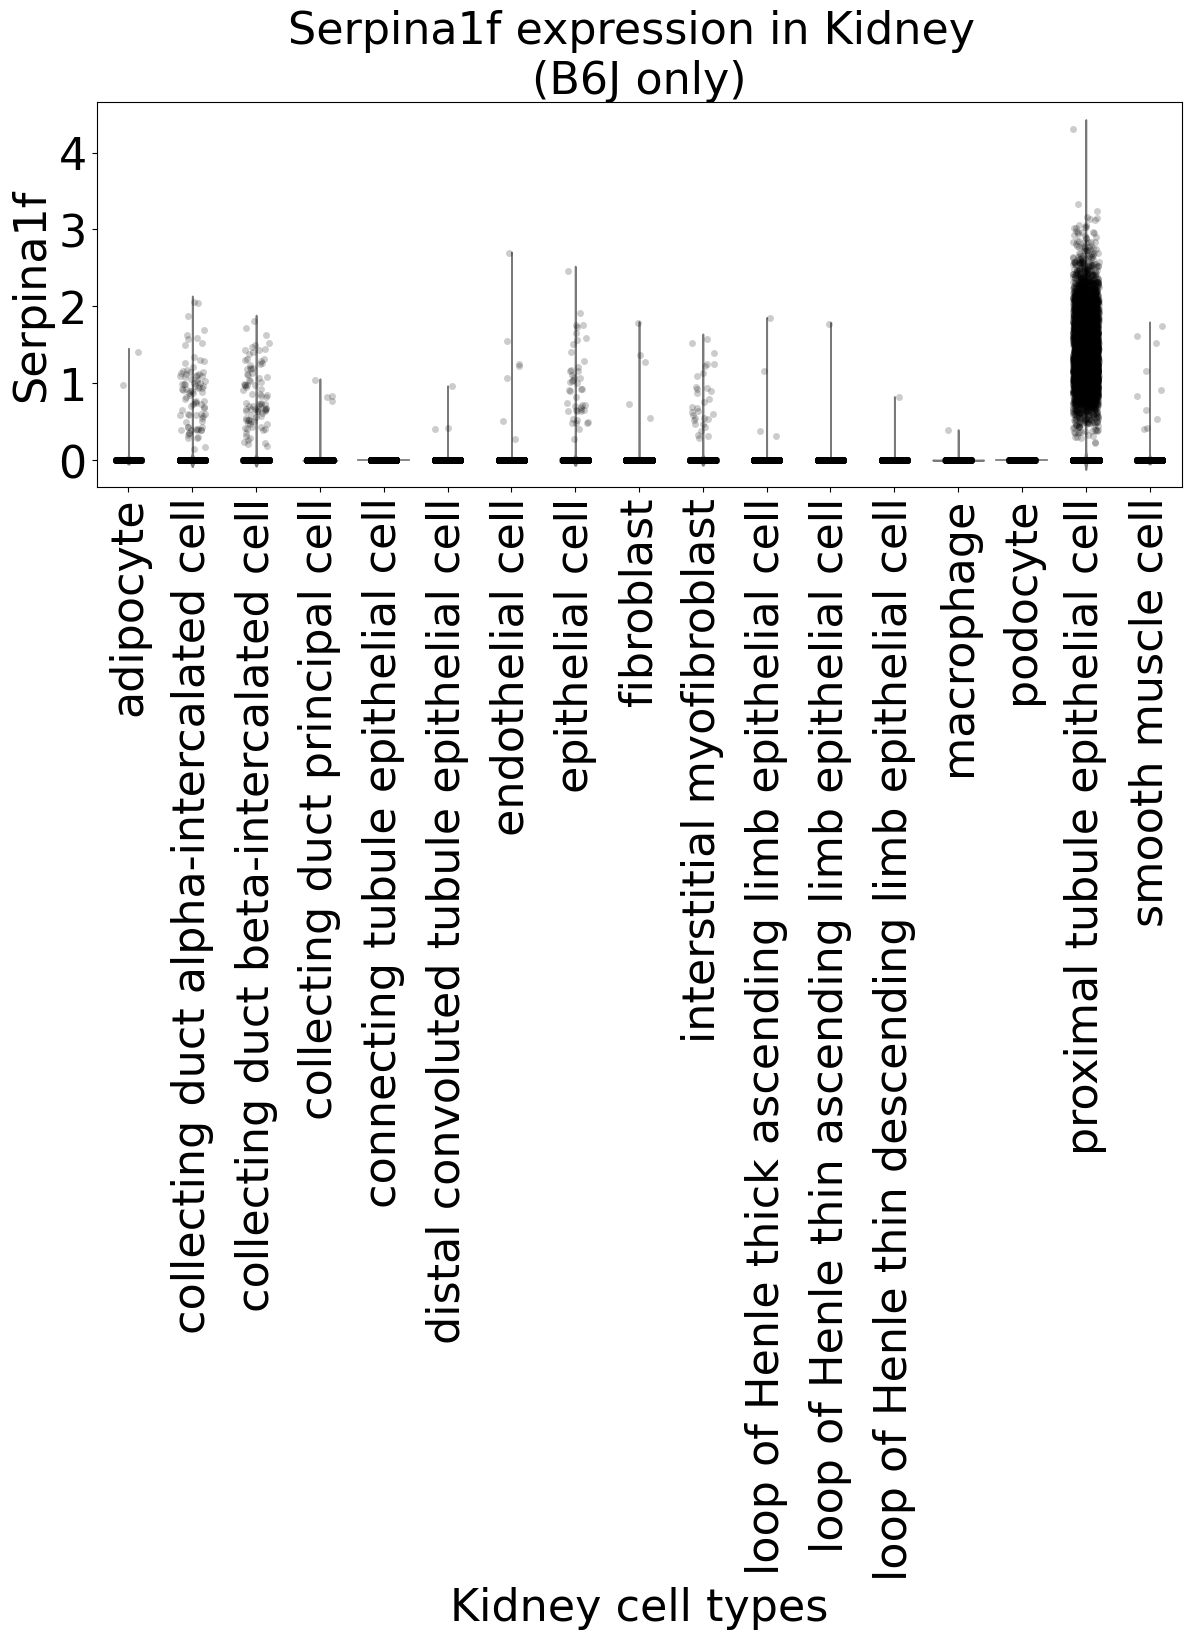

In [11]:
fontsize = 32

# ---- Specify gene + strain ----
gene = "Serpina1f"
strain = "B6J"

# collapse sexes → keep all
expr = subset_kidney[:, gene].X
expr = expr.toarray().flatten() if hasattr(expr, "toarray") else expr.flatten()

# ---- Build dataframe ----
df = pd.DataFrame({
    "expression": expr,
    "celltype": subset_kidney.obs["celltype"].values,
    "Gene": gene,
    "strain": strain
})

# ---- Plot ----
plt.figure(figsize=(14, 5))
plt.title(f"{gene} expression in Kidney \n({strain} only)", fontsize=fontsize)

sns.violinplot(
    data=df,
    x="celltype", y="expression",
    color="lightblue", inner=None
)
sns.stripplot(
    data=df,
    x="celltype", y="expression",
    color="black", jitter=0.2, alpha=0.2
)

plt.xlabel("Kidney cell types", fontsize=fontsize)
plt.ylabel(gene, fontsize=fontsize)
plt.xticks(rotation=90, fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.tight_layout()

# ---- Save ----
fig_output_path = os.path.join(output_path, "violin_plot_serpina1f_kidney.png")
plt.savefig(fig_output_path)
plt.show()


## e

In [64]:
subset_male_gonads_path = os.path.join(supplement_file_path, '8cube_other_tissues/Serpina1f_B6J_gonads.h5ad')
subset_male_gonads = ad.read_h5ad(subset_male_gonads_path)

/tmp/ipykernel_290148/3351077655.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


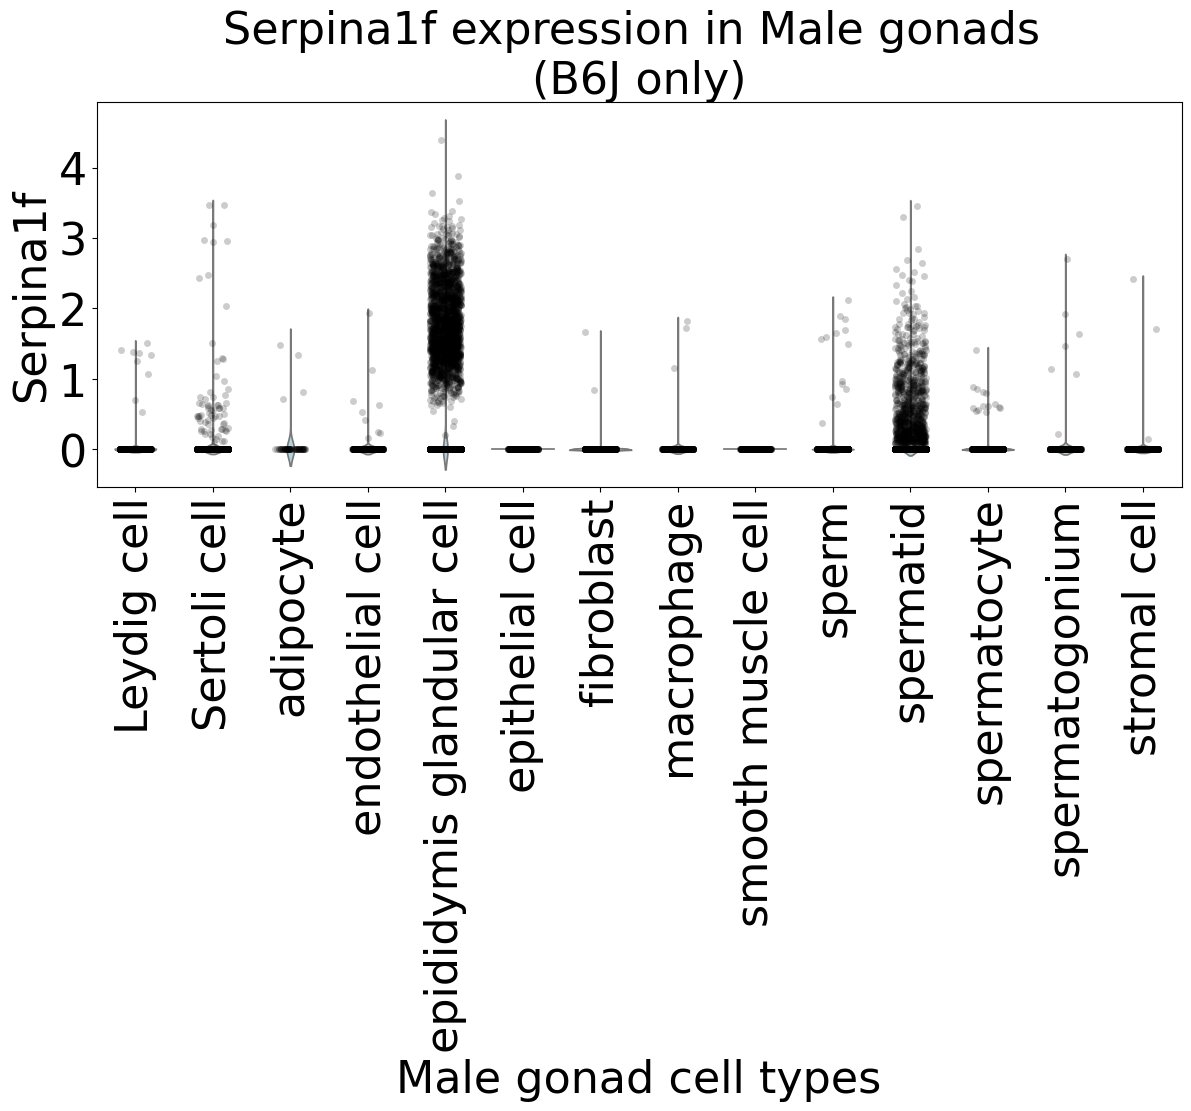

In [66]:
fontsize = 32

# ---- Specify gene + strain ----
gene = "Serpina1f"
strain = "B6J"

# collapse sexes → keep all
expr = subset_male_gonads[:, gene].X
expr = expr.toarray().flatten() if hasattr(expr, "toarray") else expr.flatten()

# ---- Build dataframe ----
df = pd.DataFrame({
    "expression": expr,
    "celltype": subset_male_gonads.obs["celltype"].values,
    "Gene": gene,
    "strain": strain
})

# ---- Plot ----
plt.figure(figsize=(14, 5))
plt.title(f"{gene} expression in Male gonads \n({strain} only)", fontsize=fontsize)

sns.violinplot(
    data=df,
    x="celltype", y="expression",
    color="lightblue", inner=None
)
sns.stripplot(
    data=df,
    x="celltype", y="expression",
    color="black", jitter=0.2, alpha=0.2
)

plt.xlabel("Male gonad cell types", fontsize=fontsize)
plt.ylabel(gene, fontsize=fontsize)
plt.xticks(rotation=90, fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.tight_layout()

# ---- Save ----
fig_output_path = os.path.join(output_path, "violin_plot_serpina1f_malegonads.png")
plt.savefig(fig_output_path)
plt.show()


## f

In [8]:
subset_liver_path = os.path.join(supplement_file_path, '8cube_other_tissues/Hpx_liver.h5ad')
subset_liver = ad.read_h5ad(subset_liver_path)

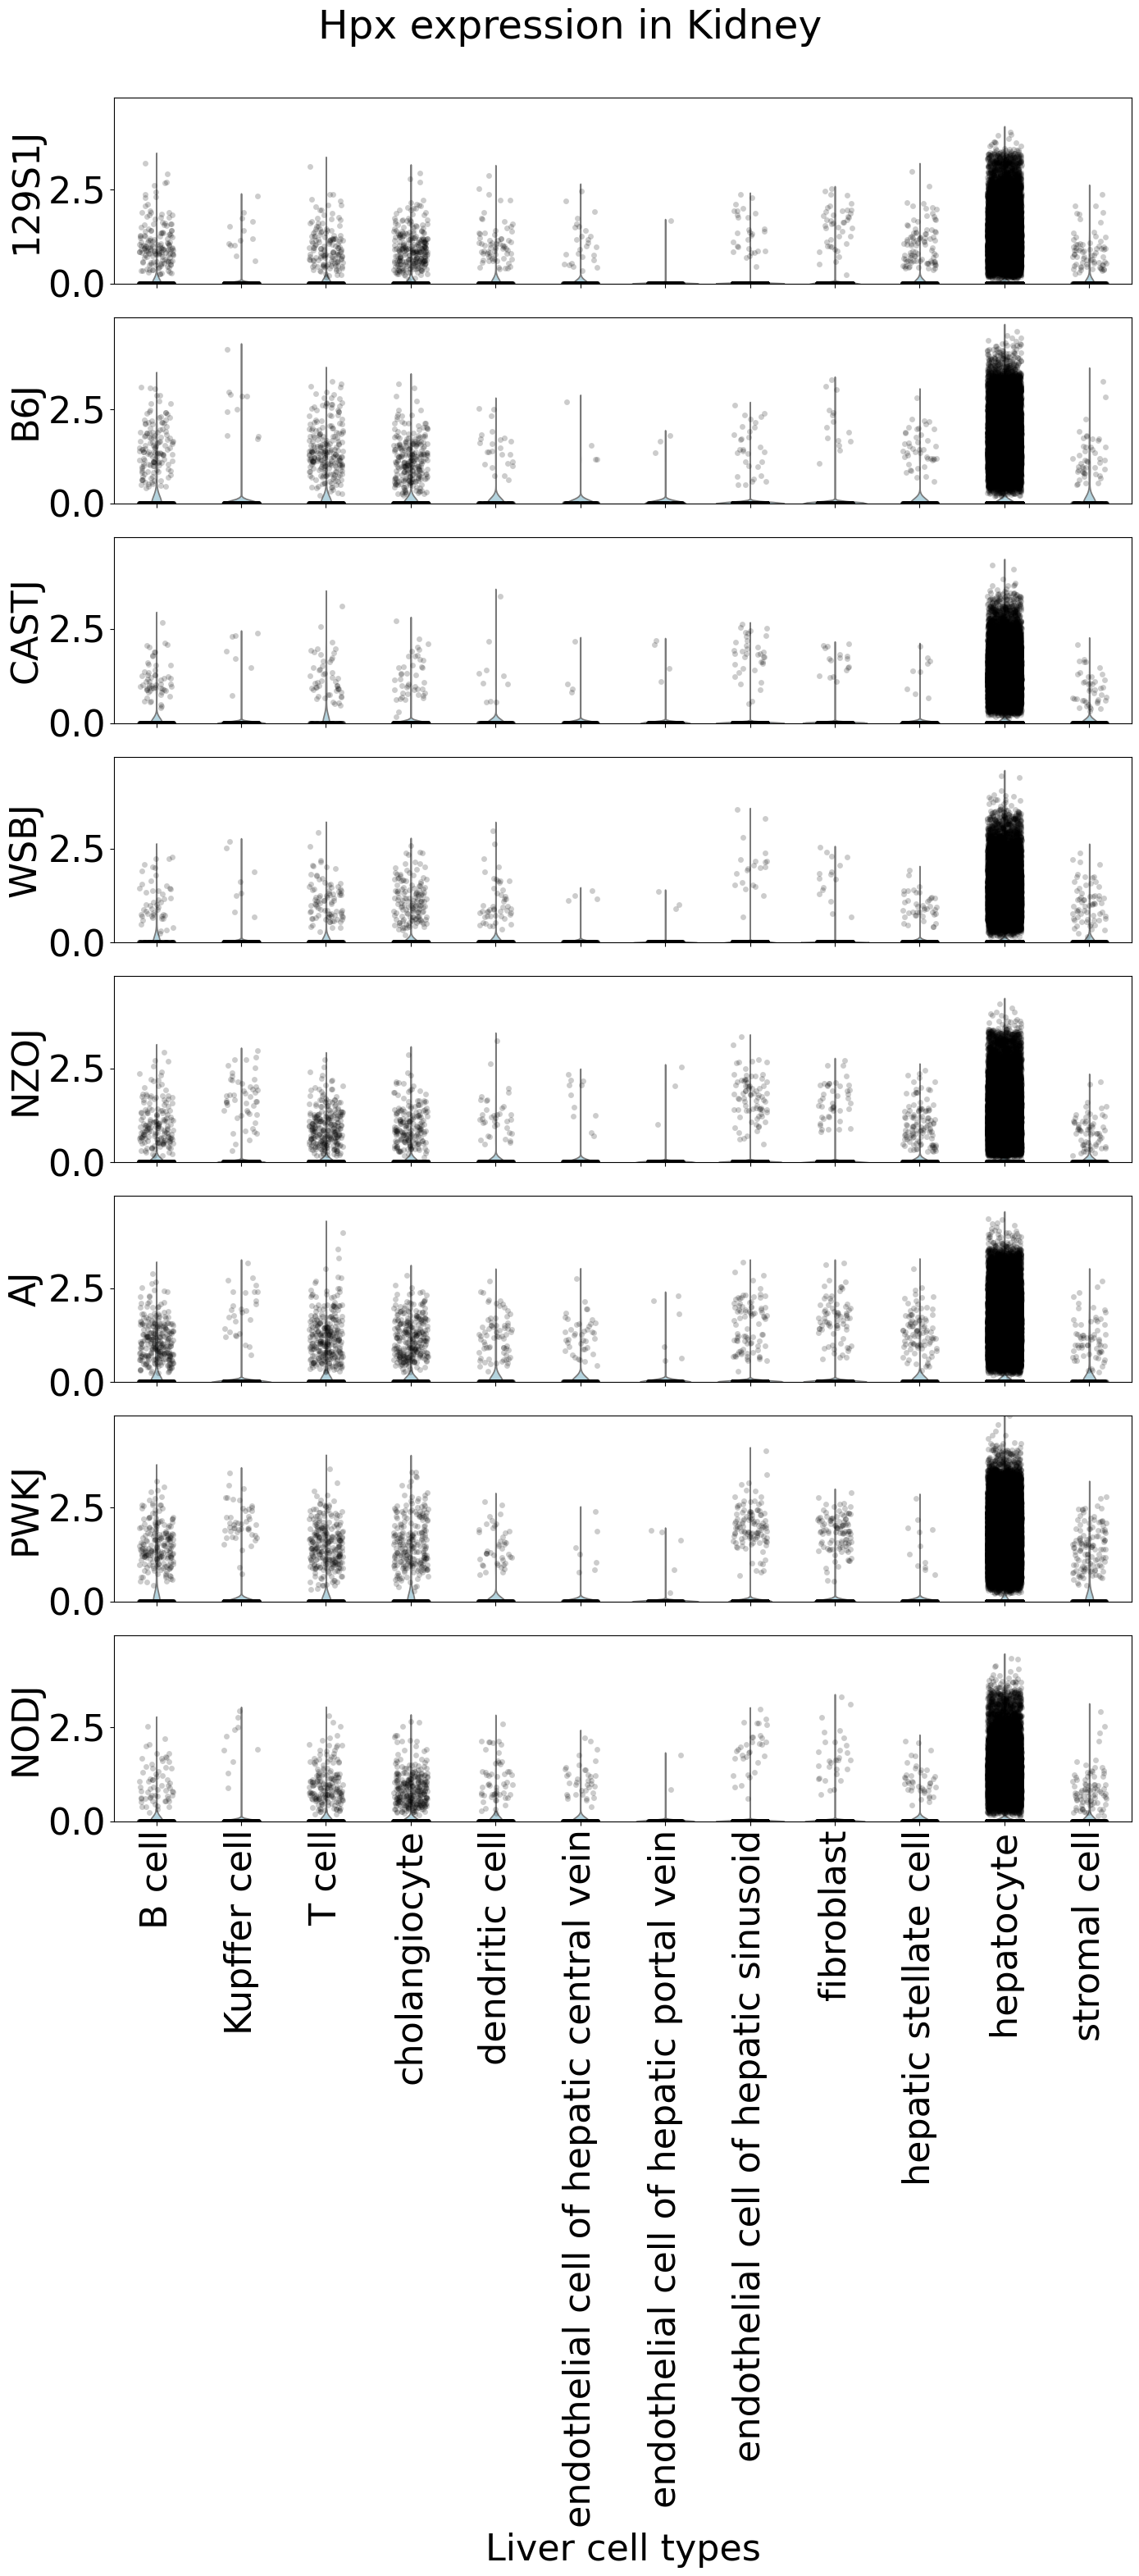

In [9]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

fontsize = 32

# ---- Settings ----
gene = "Hpx"
strains = ["129S1J", "B6J", "CASTJ", "WSBJ", "NZOJ", "AJ", "PWKJ", "NODJ"]

dfs = []

# ---- Build dataframe for each strain ----
for strain in strains:
    sub = subset_liver[subset_liver.obs["Genotype"] == strain].copy()

    expr = sub[:, gene].X
    expr = expr.toarray().flatten() if hasattr(expr, "toarray") else expr.flatten()

    df = pd.DataFrame({
        "expression": expr,
        "celltype": sub.obs["celltype"].values,
        "Gene": gene,
        "strain": strain
    })
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# ---- Global ymax across strains ----
ymax = df_all["expression"].max()

# ---- Plot stacked subplots ----
fig, axes = plt.subplots(len(strains), 1,
                         figsize=(14, 4 * len(strains)),
                         sharex=True,
                         sharey=True)

if len(strains) == 1:
    axes = [axes]

fig.suptitle(f"{gene} expression in Kidney", fontsize=fontsize+3)

for ax, strain in zip(axes, strains):
    df_strain = df_all[df_all["strain"] == strain]

    sns.violinplot(
        data=df_strain,
        x="celltype", y="expression",
        color="lightblue", inner=None, ax=ax
    )
    sns.stripplot(
        data=df_strain,
        x="celltype", y="expression",
        color="black", jitter=0.2, alpha=0.2, ax=ax
    )

    ax.set_ylabel(strain, fontsize=fontsize)  # label each panel with strain
    ax.set_ylim(0, ymax)
    ax.tick_params(axis="y", labelsize=fontsize)
    ax.tick_params(axis="x", rotation=90, labelsize=fontsize)

axes[-1].set_xlabel("Liver cell types", fontsize=fontsize)

plt.tight_layout(rect=[0, 0, 1, 0.97])

fig_output_path = os.path.join(output_path, "violin_plot_Hpx_liver.png")
plt.savefig(fig_output_path)
plt.show()

## g

In [17]:
pvals_path = os.path.join(supplement_file_path, "Developmental_kidney/Age.csv")
pvals = pd.read_csv(pvals_path, index_col = "gene_name")

#global testing correction for psi and zeta
_, pvals['Psi FDR'], _, _ = multipletests(pvals['Psi p-value'], method='fdr_bh')
_, pvals['Zeta FDR'], _, _ = multipletests(pvals['Zeta p-value'], method='fdr_bh')

filtered = pvals[(pvals['Psi FDR'] < 0.05) & 
                          (pvals['Zeta FDR'] < 0.05)
                         ]

df_path = os.path.join(supplement_file_path, "Developmental_kidney/psi_block_Age.csv")
df = pd.read_csv(df_path, index_col = "gene_name")
df = df.drop(["ensembl_id"], axis = 1)
clusters = sorted(df.columns)
df = df.loc[filtered.index]

In [20]:
# Set seeds for full reproducibility
SEED = 45
np.random.seed(SEED)
random.seed(SEED)

# Use a fixed seed for Leiden
rng = np.random.default_rng(SEED)

# X = numpy array from the contribution score DataFrame
X = df.values  # shape (n_genes, 17)

# Build kNN graph — 10 neighbors usually works well
k = 10
nn = NearestNeighbors(n_neighbors=k, metric='cosine')
nn.fit(X)
distances, indices = nn.kneighbors(X)

# Construct undirected edges
edges = []
for i in range(indices.shape[0]):
    for j in indices[i]:
        if i != j:
            edges.append((i, j))

# Build iGraph object
g = ig.Graph(edges=edges, directed=False)

# Run Leiden clustering with a fixed random state
partition = leidenalg.find_partition(
    g,
    leidenalg.RBConfigurationVertexPartition,
    seed=SEED  # This ensures deterministic clustering
)

# Get cluster labels
labels = np.array(partition.membership)
df['cluster'] = labels

# Compute cluster sizes
cluster_counts = df['cluster'].value_counts().sort_index()  # Index matches cluster label

# Compute cluster profiles
cluster_profiles = df.groupby('cluster').mean().drop(columns='cluster', errors='ignore')

#sort heatmap data
heatmap_data = cluster_profiles
heatmap_data = heatmap_data[['E16.5', 'P0', 'W3', 'W12', 'W52', 'W92']]

# Update y-axis labels with gene counts
cluster_labels = [f"Cluster {i} (n={cluster_counts[i]})" for i in heatmap_data.index]

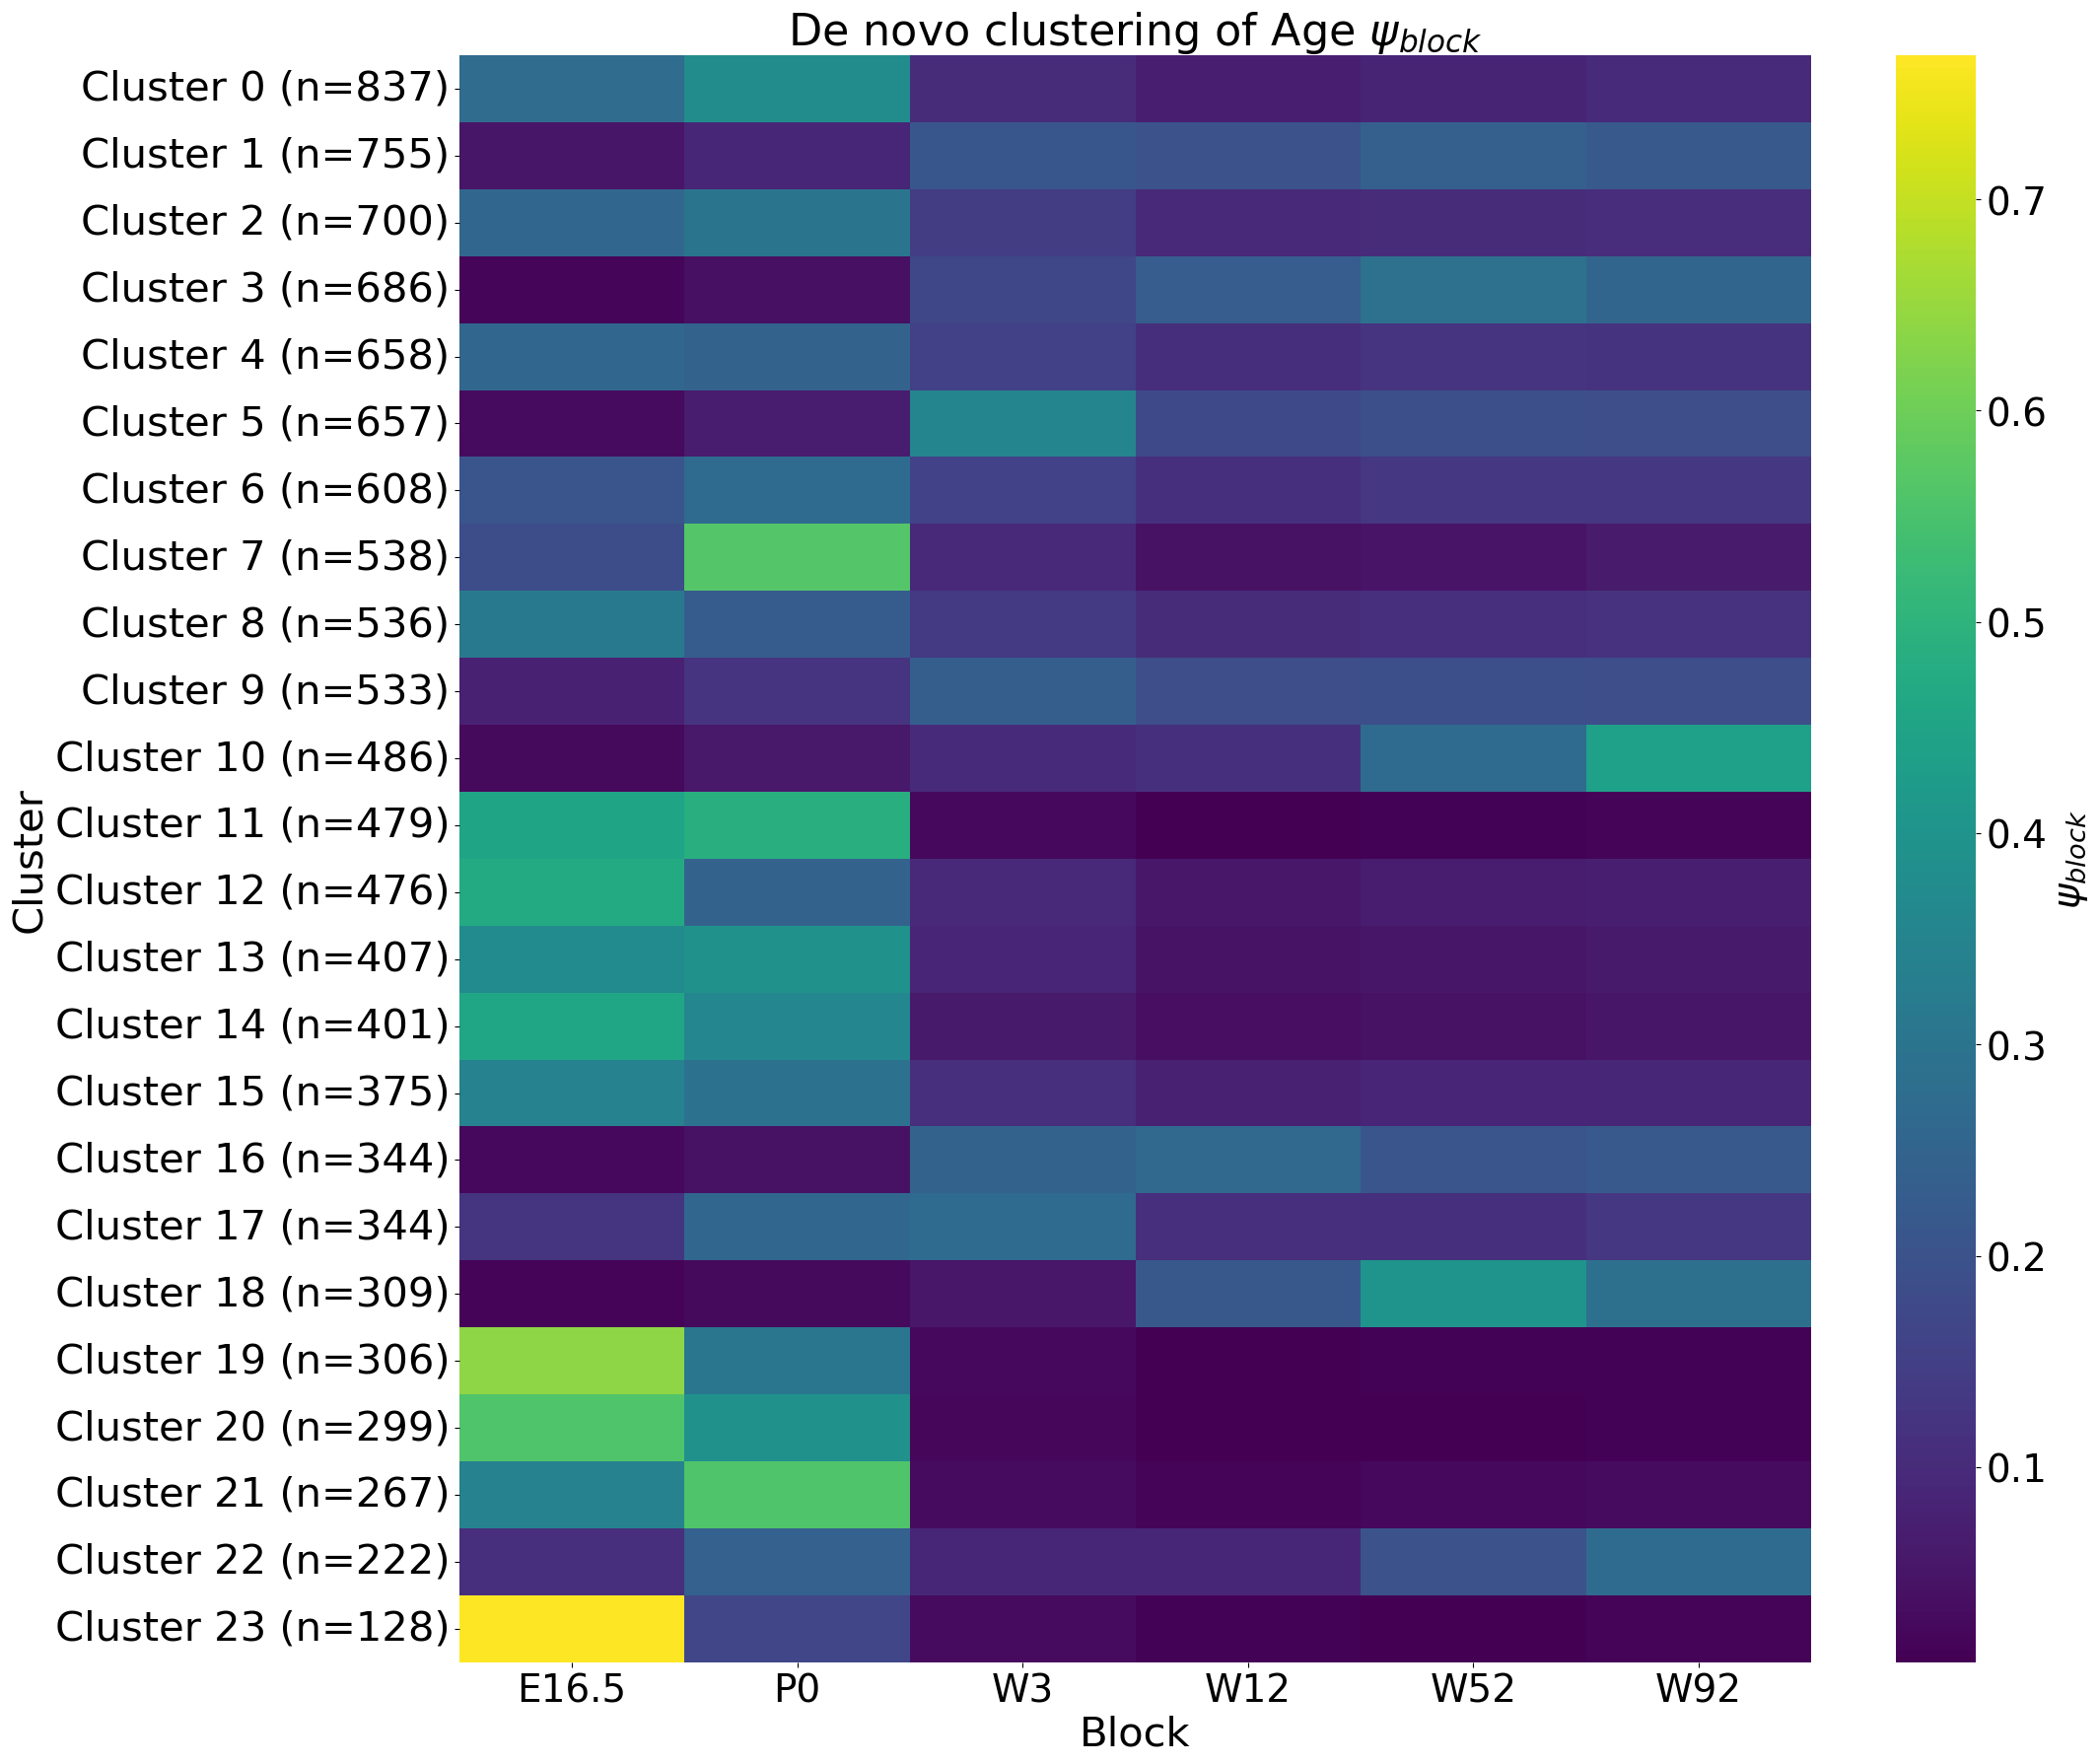

<Figure size 640x480 with 0 Axes>

In [21]:
# Plot heatmap
fontsize = 30
plt.figure(figsize=(22, 18))
ax = sns.heatmap(heatmap_data, cmap='viridis', xticklabels=True, yticklabels=cluster_labels)

# Colorbar and axis labels
colorbar = ax.collections[0].colorbar
colorbar.set_label('$\psi_{{block}}$', fontsize=fontsize-2)
colorbar.ax.tick_params(labelsize=fontsize -2)

plt.title(f"De novo clustering of Age $\psi_{{block}}$", fontsize=fontsize+2)
plt.xlabel("Block", fontsize=fontsize)
plt.ylabel("Cluster", fontsize=fontsize)
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize, rotation=0)
plt.tight_layout()
plt.show()
fig_output_path = os.path.join(output_path, "age_heatmap.png")
plt.savefig(fig_output_path)

## h

In [22]:
subset_adata_path = os.path.join(supplement_file_path, "Developmental_kidney/Dev_kidney_fig_2_3_genes.h5ad")
subset_adata = ad.read_h5ad(subset_adata_path)

In [23]:
# Create the dictionary
ensembl_to_symbol = dict(zip(subset_adata.var.index, subset_adata.var["gene_symbols"]))
symbol_to_ensembl = {v: k for k, v in ensembl_to_symbol.items()}

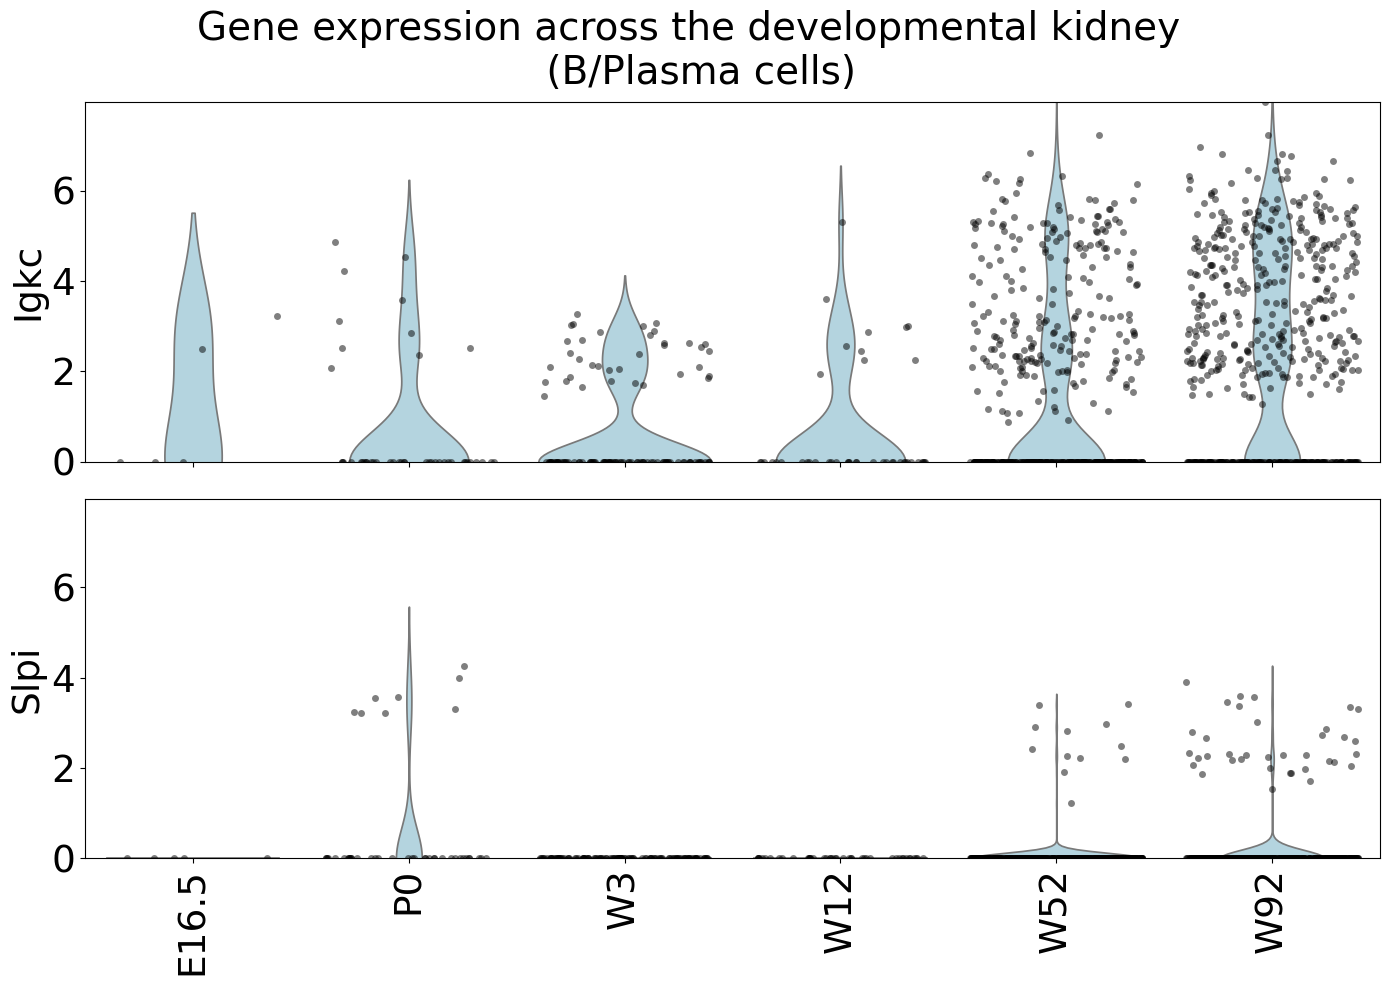

In [24]:
#subset to B/Plasma cells
bplasma = subset_adata[subset_adata.obs['celltype_final'] == 'B/Plasma']
genes_to_plot = ["Igkc", "Slpi" ]
fontsize = 27

# Build dataframe
dfs = []
for gene in genes_to_plot:
    ensg = symbol_to_ensembl[gene]
    expr = bplasma[:, ensg].X
    expr = expr.toarray().flatten() if hasattr(expr, "toarray") else expr.flatten()
    
    df = pd.DataFrame({
        "expression": expr,
        "Age": bplasma.obs["Age"].values,
        "Gene": gene
    })
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Global y-axis limits
ymax = df_all["expression"].max()


# Create stacked subplots
fig, axes = plt.subplots(len(genes_to_plot), 1, figsize=(14, 5*len(genes_to_plot)), sharey=True, sharex = True)

# Figure-wide title
fig.suptitle("Gene expression across the developmental kidney \n (B/Plasma cells)", fontsize=fontsize+1)

if len(genes_to_plot) == 1:
    axes = [axes]

for ax, gene in zip(axes, genes_to_plot):
    df_gene = df_all[df_all["Gene"] == gene]
    sns.violinplot(
        data=df_gene,
        x="Age", y="expression",
        color='lightblue',
        inner=None,
        ax=ax
    )
    sns.stripplot(
        data=df_gene,
        x="Age", y="expression",
        color="black", jitter=0.4, alpha=0.5,
        ax=ax
    )
    ax.set_ylabel(gene, fontsize=fontsize)
    ax.set_xlabel("")
    ax.set_ylim(0, ymax)
    ax.tick_params(axis="x", rotation=90, labelsize=fontsize)
    ax.tick_params(axis="y", labelsize=fontsize)

plt.tight_layout()
fig_out_path = os.path.join(output_path,"dev_kidney_violin.png" )
plt.savefig(fig_out_path)
plt.show()